In [1]:
pip install opencv-python numpy matplotlib

  Using cached opencv_python-4.13.0.92-cp37-abi3-win_amd64.whl.metadata (20 kB)
  Using cached numpy-2.4.3-cp312-cp312-win_amd64.whl.metadata (6.6 kB)
  Using cached matplotlib-3.10.8-cp312-cp312-win_amd64.whl.metadata (52 kB)
  Using cached contourpy-1.3.3-cp312-cp312-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.62.1-cp312-cp312-win_amd64.whl.metadata (119 kB)
  Using cached kiwisolver-1.5.0-cp312-cp312-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.1.1-cp312-cp312-win_amd64.whl.metadata (9.0 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached opencv_python-4.13.0.92-cp37-abi3-win_amd64.whl (40.2 MB)
Using cached numpy-2.4.3-cp312-cp312-win_amd64.whl (12.3 MB)
Using cached matplotlib-3.10.8-cp312-cp312-win_amd64.whl (8.1 MB)
Using cached contourpy-1.3.3-cp312-cp312-win_amd64.whl (226 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.62.


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Fruits:
Otsu Threshold = 172.0
Number of objects = 19


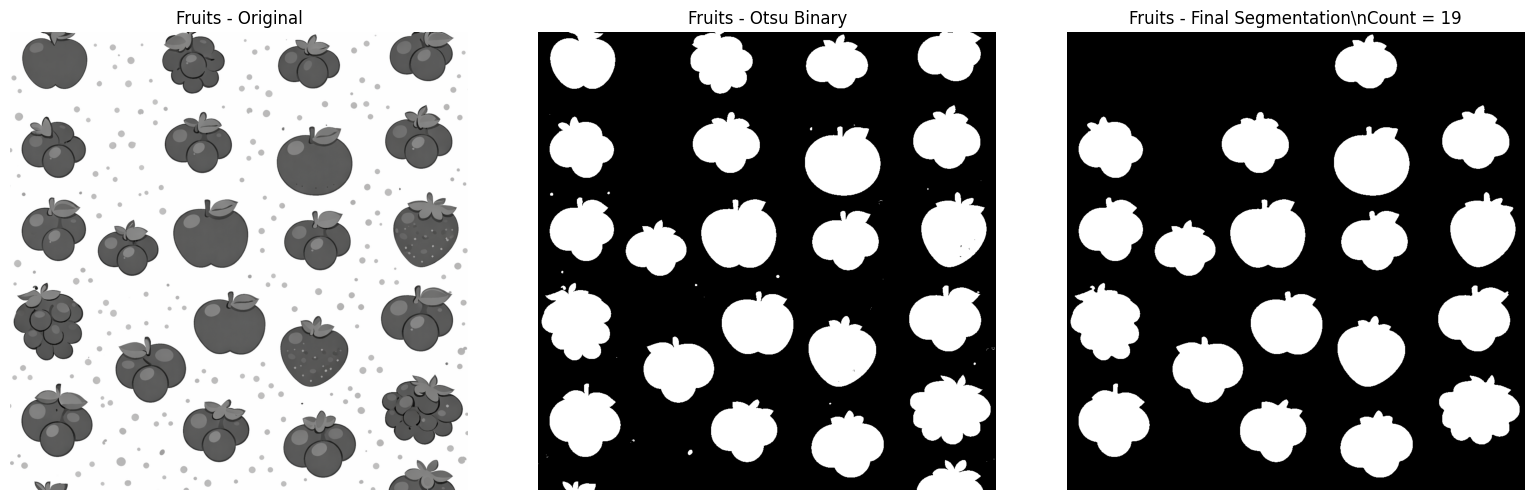

Monsters:
Otsu Threshold = 77.0
Number of objects = 18


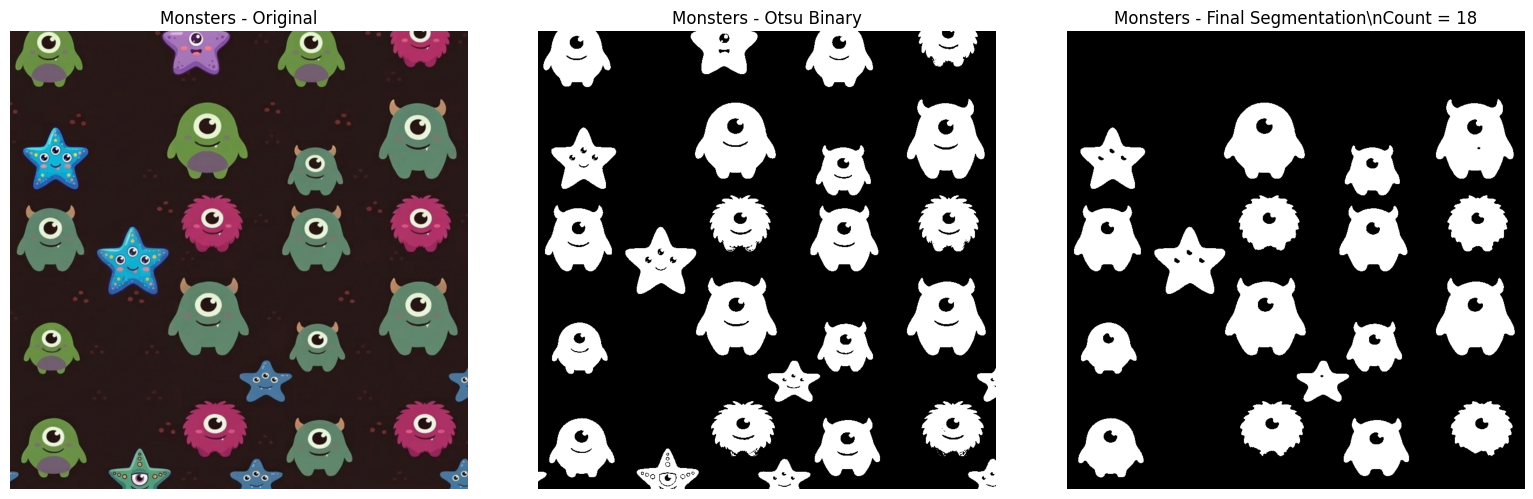

Strawberries:
Otsu Threshold = 84.0
Number of objects = 21


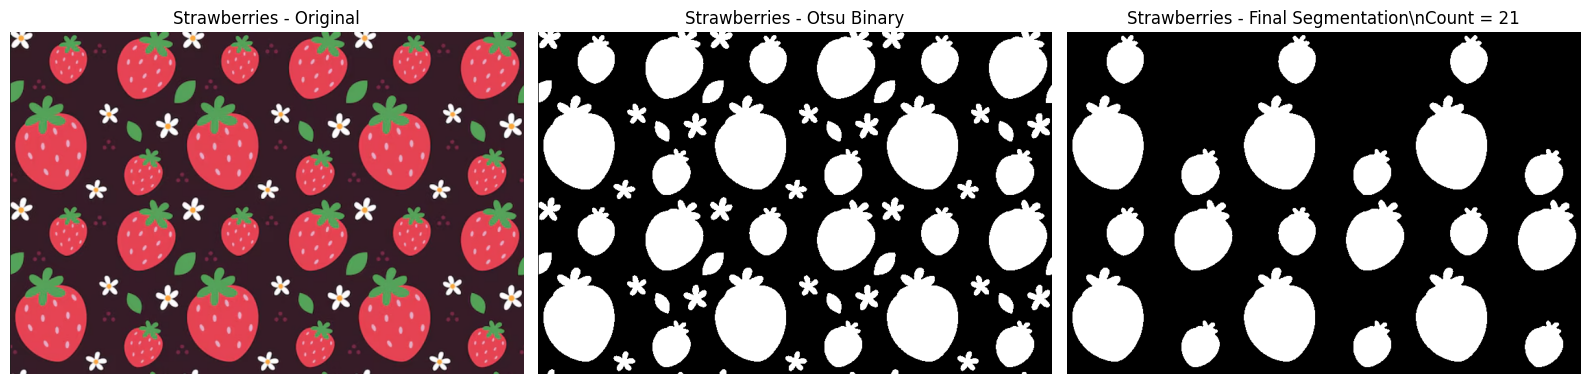

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (8, 8)


def morphological_reconstruction(marker, mask, kernel):
  
    prev = np.zeros_like(marker)
    curr = marker.copy()

    while True:
        dilated = cv2.dilate(curr, kernel, iterations=1)
        curr = cv2.bitwise_and(dilated, mask)

        if np.array_equal(curr, prev):
            return curr

        prev = curr.copy()


def remove_border_objects(binary):
    
    marker = np.zeros_like(binary)

    marker[0, :] = binary[0, :]
    marker[-1, :] = binary[-1, :]
    marker[:, 0] = np.maximum(marker[:, 0], binary[:, 0])
    marker[:, -1] = np.maximum(marker[:, -1], binary[:, -1])

    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
    border_objects = morphological_reconstruction(marker, binary, kernel)

    cleared = cv2.subtract(binary, border_objects)
    return cleared


def area_filter(binary, min_area):
    
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(
        (binary > 0).astype(np.uint8), connectivity=8
    )

    output = np.zeros_like(binary)
    count = 0

    for label in range(1, num_labels):  # skip background
        area = stats[label, cv2.CC_STAT_AREA]
        if area >= min_area:
            output[labels == label] = 255
            count += 1

    return output, count


def segment_image(image_path, open_k=3, close_k=5, min_area=1000):
   
    image = cv2.imread(image_path)
    if image is None:
        raise FileNotFoundError(f"Cannot read image: {image_path}")

    rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    otsu_threshold, thresh = cv2.threshold(
        gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    border_pixels = np.concatenate([
        thresh[0, :], thresh[-1, :], thresh[:, 0], thresh[:, -1]
    ])
    if np.mean(border_pixels) > 127:
        binary = cv2.bitwise_not(thresh)
    else:
        binary = thresh

    open_kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (open_k, open_k))
    close_kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (close_k, close_k))

    opened = cv2.morphologyEx(binary, cv2.MORPH_OPEN, open_kernel)
    closed = cv2.morphologyEx(opened, cv2.MORPH_CLOSE, close_kernel)

    cleared = remove_border_objects(closed)
    
    final_mask, count = area_filter(cleared, min_area)

    return {
        "original": rgb,
        "gray": gray,
        "binary": binary,
        "opened": opened,
        "closed": closed,
        "cleared": cleared,
        "final_mask": final_mask,
        "count": count,
        "otsu_threshold": otsu_threshold
    }


def show_results(title, result):
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    axes[0].imshow(result["original"])
    axes[0].set_title(f"{title} - Original")
    axes[0].axis("off")

    axes[1].imshow(result["binary"], cmap="gray")
    axes[1].set_title(f"{title} - Otsu Binary")
    axes[1].axis("off")

    axes[2].imshow(result["final_mask"], cmap="gray")
    axes[2].set_title(f"{title} - Final Segmentation\\nCount = {result['count']}")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()



fruit_path = "Fruits.jpg"
monster_path = "Monsters.jpg"
strawberry_path = "Strawberries.jpg"


fruit_result = segment_image(fruit_path, open_k=3, close_k=5, min_area=4000)
monster_result = segment_image(monster_path, open_k=3, close_k=5, min_area=3000)
strawberry_result = segment_image(strawberry_path, open_k=3, close_k=3, min_area=1500)

print("Fruits:")
print("Otsu Threshold =", fruit_result["otsu_threshold"])
print("Number of objects =", fruit_result["count"])
show_results("Fruits", fruit_result)

print("Monsters:")
print("Otsu Threshold =", monster_result["otsu_threshold"])
print("Number of objects =", monster_result["count"])
show_results("Monsters", monster_result)

print("Strawberries:")
print("Otsu Threshold =", strawberry_result["otsu_threshold"])
print("Number of objects =", strawberry_result["count"])
show_results("Strawberries", strawberry_result)